In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import copy

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize & reshape
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Dataset Loaded.")


Dataset Loaded.


In [ ]:
def create_iid_clients(num_clients=5):
    data_per_client = len(x_train) // num_clients
    clients = []

    indices = np.arange(len(x_train))
    np.random.shuffle(indices)

    for i in range(num_clients):
        start = i * data_per_client
        end = (i + 1) * data_per_client
        client_x = x_train[indices[start:end]]
        client_y = y_train[indices[start:end]]
        clients.append((client_x, client_y))

    return clients

clients_iid = create_iid_clients(5)
print("Created 5 IID Clients.")


Created 5 IID Clients.


In [ ]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [ ]:
def train_local_models(clients, epochs=10):
    client_models = []
    for (client_x, client_y) in clients:
        model = build_cnn()
        model.fit(client_x, client_y, epochs=epochs, verbose=0)
        client_models.append(model)
    return client_models

print("Training 5 client models for 10 epochs...")
client_models = train_local_models(clients_iid, epochs=10)
print("Training complete.")


Training 5 client models for 10 epochs...
Training complete.


In [ ]:
def fedavg_aggregate(client_models):
    weights = [m.get_weights() for m in client_models]
    avg = [np.mean(w, axis=0) for w in zip(*weights)]

    global_model = build_cnn()
    global_model.set_weights(avg)
    return global_model


In [ ]:
def qpso_aggregate(client_models, x_val, y_val, q_iters=8, beta=0.6, verbose=1):
    n_particles = len(client_models)

    # model template
    template = client_models[0]
    global_model = tf.keras.models.clone_model(template)
    global_model.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    # Compute FedAvg for non-optimized layers
    fedavg = fedavg_aggregate(client_models).get_weights()

    shapes = [w.shape for w in fedavg]
    flats = [np.prod(s) for s in shapes]

    # flatten weights of each layer for each client
    layer_particles = []
    for layer_idx in range(len(fedavg)):
        layer_vecs = []
        for m in client_models:
            w = m.get_weights()[layer_idx].reshape(-1)
            layer_vecs.append(w)
        layer_particles.append(np.stack(layer_vecs))  # (n_clients, dim)

    # fitness evaluation
    def eval_loss(layer_idx, flat_candidate):
        temp = [w.copy() for w in fedavg]
        temp[layer_idx] = flat_candidate.reshape(shapes[layer_idx])
        global_model.set_weights(temp)
        return global_model.evaluate(x_val, y_val, verbose=0)[0]

    optimized_layers = [None] * len(fedavg)

    for layer_idx in range(len(fedavg)):
        positions = layer_particles[layer_idx].copy()
        pbest = positions.copy()
        pbest_scores = np.array([eval_loss(layer_idx, p)
                                 for p in pbest])

        gbest_idx = np.argmin(pbest_scores)
        gbest = pbest[gbest_idx].copy()
        gbest_score = pbest_scores[gbest_idx]

        if verbose:
            print(f"\n[Layer {layer_idx}] dim={positions.shape[1]} initial_best={gbest_score:.4f}")

        for it in range(q_iters):
            mbest = np.mean(pbest, axis=0)
            dim = positions.shape[1]
            for i in range(n_particles):
                u = np.random.rand(dim)
                sign = np.where(np.random.rand(dim) > 0.5, 1, -1)

                x = positions[i]
                p = pbest[i]

                step = beta * np.abs(mbest - x) * np.log(1/(u+1e-9)) * sign
                new_pos = p + step

                positions[i] = new_pos
                score = eval_loss(layer_idx, new_pos)

                if score < pbest_scores[i]:
                    pbest_scores[i] = score
                    pbest[i] = new_pos.copy()

                if score < gbest_score:
                    gbest_score = score
                    gbest = new_pos.copy()

            if verbose:
                print(f"  iter {it+1}/{q_iters} — best_loss={gbest_score:.4f}")

        optimized_layers[layer_idx] = gbest.reshape(shapes[layer_idx])

    global_model.set_weights(optimized_layers)
    global_model.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    print("\nQPSO aggregation complete.")
    return global_model


In [ ]:
val_size = 3000
x_val = x_train[:val_size]
y_val = y_train[:val_size]

print("Validation set ready.")


Validation set ready.


In [ ]:
print("Running QPSO Aggregation on IID 5 Clients...")
global_qpso_model = qpso_aggregate(
    client_models,
    x_val, y_val,
    q_iters=6,      # balanced speed/quality
    beta=0.6,
    verbose=1
)

print("Evaluating QPSO Aggregated Model:")
loss, acc = global_qpso_model.evaluate(x_test, y_test, verbose=2)
print(f"Final QPSO Accuracy = {acc:.4f}")


Running QPSO Aggregation on IID 5 Clients...

[Layer 0] dim=288 initial_best=1.1569
  iter 1/6 — best_loss=1.1569
  iter 2/6 — best_loss=1.1569
  iter 3/6 — best_loss=1.1569
  iter 4/6 — best_loss=1.1569
  iter 5/6 — best_loss=1.1569
  iter 6/6 — best_loss=1.1569

[Layer 1] dim=32 initial_best=1.7364
  iter 1/6 — best_loss=1.7193
  iter 2/6 — best_loss=1.7193
  iter 3/6 — best_loss=1.7193
  iter 4/6 — best_loss=1.7193
  iter 5/6 — best_loss=1.7037
  iter 6/6 — best_loss=1.7037

[Layer 2] dim=346112 initial_best=1.8163
  iter 1/6 — best_loss=1.8150
  iter 2/6 — best_loss=1.8100
  iter 3/6 — best_loss=1.8100
  iter 4/6 — best_loss=1.8100
  iter 5/6 — best_loss=1.8100
  iter 6/6 — best_loss=1.8100

[Layer 3] dim=64 initial_best=1.7607
  iter 1/6 — best_loss=1.7607
  iter 2/6 — best_loss=1.7607
  iter 3/6 — best_loss=1.7607
  iter 4/6 — best_loss=1.7607
  iter 5/6 — best_loss=1.7601
  iter 6/6 — best_loss=1.7470

[Layer 4] dim=640 initial_best=1.8465
  iter 1/6 — best_loss=1.8465
  iter 2/

In [ ]:
def evaluate_all(clients, client_models, global_avg_model, global_qpso_model):
    rows = []

    # client accuracies
    for i, model in enumerate(client_models):
        loss, acc = model.evaluate(x_test, y_test, verbose=0)
        rows.append([f"Client {i+1}", acc])

    # FedAvg
    loss, acc = global_avg_model.evaluate(x_test, y_test, verbose=0)
    rows.append(["FedAvg", acc])

    # QPSO
    loss, acc = global_qpso_model.evaluate(x_test, y_test, verbose=0)
    rows.append(["QPSO", acc])

    df = pd.DataFrame(rows, columns=["Model", "Accuracy"])
    return df

global_fedavg = fedavg_aggregate(client_models)
results_table = evaluate_all(clients_iid, client_models, global_fedavg, global_qpso_model)

print("\n=== RESULTS TABLE ===")
print(results_table)



=== RESULTS TABLE ===
      Model  Accuracy
0  Client 1    0.9726
1  Client 2    0.9770
2  Client 3    0.9747
3  Client 4    0.9704
4  Client 5    0.9728
5    FedAvg    0.4125
6      QPSO    0.8151


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_predictions(model):
    preds = model.predict(x_test, verbose=0)
    preds = preds.argmax(axis=1)
    return preds

# Predictions
preds_fedavg = get_predictions(global_fedavg)
preds_qpso = get_predictions(global_qpso_model)

# Metrics
print("===== FEDAVG METRICS =====")
print(classification_report(y_test, preds_fedavg))

print("\n===== QPSO METRICS =====")
print(classification_report(y_test, preds_qpso))


===== FEDAVG METRICS =====
              precision    recall  f1-score   support

           0       1.00      0.04      0.07       980
           1       0.99      0.38      0.55      1135
           2       0.94      0.32      0.48      1032
           3       0.55      0.84      0.67      1010
           4       0.26      0.26      0.26       982
           5       0.91      0.25      0.39       892
           6       0.97      0.14      0.24       958
           7       0.92      0.68      0.78      1028
           8       0.19      0.99      0.31       974
           9       0.62      0.20      0.30      1009

    accuracy                           0.41     10000
   macro avg       0.73      0.41      0.41     10000
weighted avg       0.74      0.41      0.41     10000


===== QPSO METRICS =====
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       1.00      0.08      0.14      1135
           2       0.98  

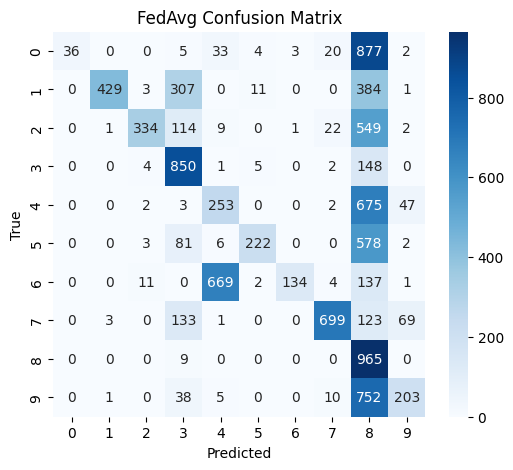

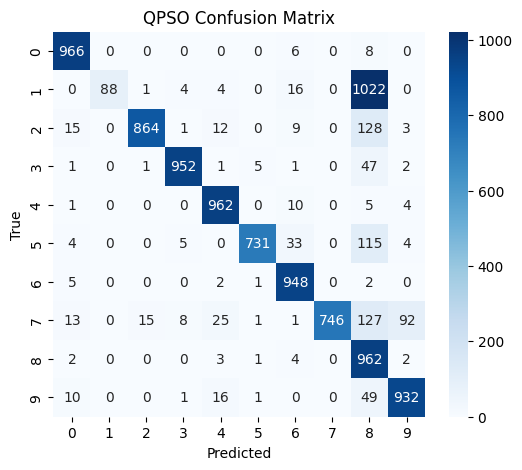

In [ ]:
def plot_conf_matrix(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

cm_fedavg = confusion_matrix(y_test, preds_fedavg)
cm_qpso = confusion_matrix(y_test, preds_qpso)

plot_conf_matrix(cm_fedavg, "FedAvg Confusion Matrix")
plot_conf_matrix(cm_qpso, "QPSO Confusion Matrix")


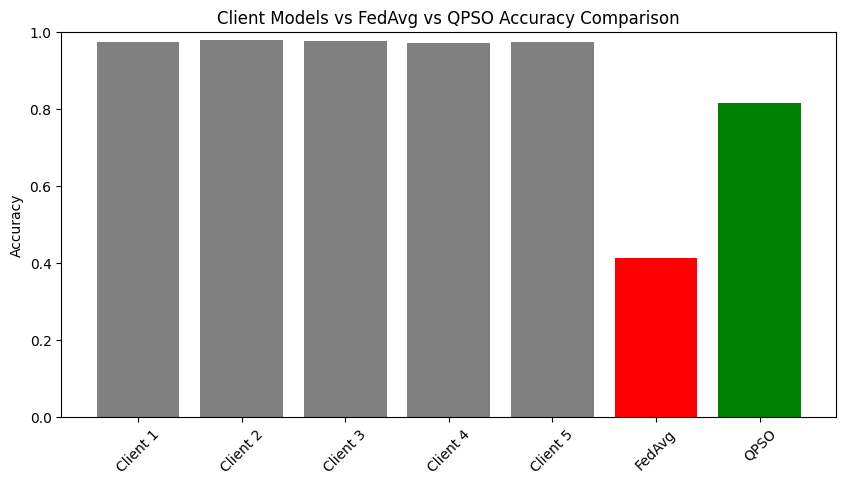

In [ ]:
import matplotlib.pyplot as plt

names = ["Client 1","Client 2","Client 3","Client 4","Client 5","FedAvg","QPSO"]
accs = [
    results_table.loc[0, "Accuracy"],
    results_table.loc[1, "Accuracy"],
    results_table.loc[2, "Accuracy"],
    results_table.loc[3, "Accuracy"],
    results_table.loc[4, "Accuracy"],
    results_table.loc[5, "Accuracy"],
    results_table.loc[6, "Accuracy"],
]

plt.figure(figsize=(10,5))
plt.bar(names, accs, color=["gray"]*5 + ["red","green"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Client Models vs FedAvg vs QPSO Accuracy Comparison")
plt.ylim(0,1)
plt.show()


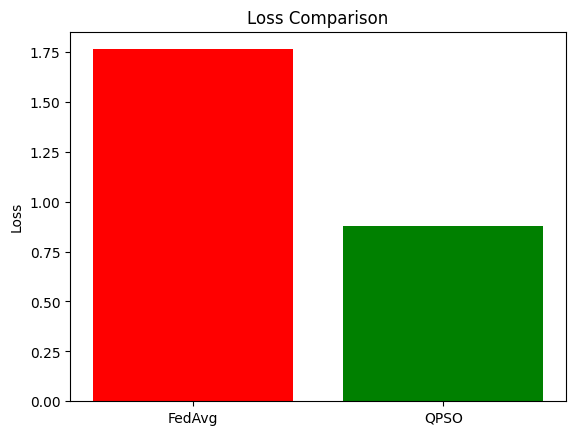

In [ ]:
import numpy as np

loss_fedavg = global_fedavg.evaluate(x_test, y_test, verbose=0)[0]
loss_qpso = global_qpso_model.evaluate(x_test, y_test, verbose=0)[0]

plt.bar(["FedAvg", "QPSO"], [loss_fedavg, loss_qpso], color=["red","green"])
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.show()


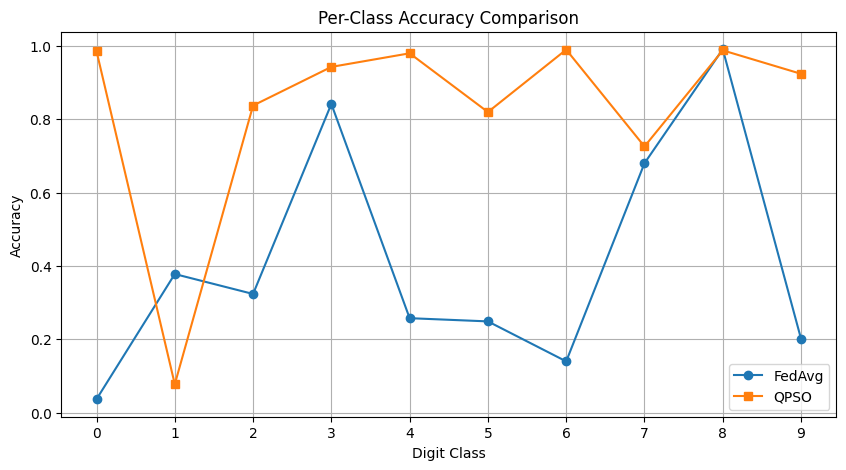

In [ ]:
def per_class_accuracy(y_true, y_pred):
    accs = []
    for c in range(10):
        idx = np.where(y_true == c)[0]
        acc = (y_pred[idx] == c).mean()
        accs.append(acc)
    return accs

acc_fedavg_class = per_class_accuracy(y_test, preds_fedavg)
acc_qpso_class = per_class_accuracy(y_test, preds_qpso)

plt.figure(figsize=(10,5))
plt.plot(acc_fedavg_class, marker='o', label="FedAvg")
plt.plot(acc_qpso_class, marker='s', label="QPSO")
plt.title("Per-Class Accuracy Comparison")
plt.xlabel("Digit Class")
plt.ylabel("Accuracy")
plt.xticks(range(10))
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import cosine
import math

# helper: flatten a numpy array
def flatten_np(x):
    return x.reshape(-1)

# cosine similarity matrix for a list of vectors (rows = vectors)
def cosine_sim_matrix(vectors):
    # vectors: (n_vectors, dim)
    # using normalized dot product
    norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
    norms_vec = norms * norms.T
    sim = (vectors @ vectors.T) / norms_vec
    return sim


In [ ]:
# use model[0] as template
template = client_models[0]
vars_template = template.trainable_variables  # tf.Variables in Keras order
print("Number of trainable variables:", len(vars_template))

# Create readable names and shapes
var_info = []
for v in vars_template:
    var_info.append((v.name, tuple(v.shape)))

for i, (name, shape) in enumerate(var_info):
    print(i, name, shape)


Number of trainable variables: 6
0 kernel (3, 3, 1, 32)
1 bias (32,)
2 kernel (5408, 64)
3 bias (64,)
4 kernel (64, 10)
5 bias (10,)


In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

def compute_gradients_on_val(model, x_val, y_val, batch_size=256):
    # compute gradients averaged over validation set (we do a single pass average)
    dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size)
    grads_sum = [np.zeros(v.shape, dtype=np.float32) for v in model.trainable_variables]
    n_batches = 0
    for xb, yb in dataset:
        with tf.GradientTape() as tape:
            preds = model(xb, training=False)
            loss = loss_fn(yb, preds)
        grads = tape.gradient(loss, model.trainable_variables)
        grads = [g.numpy() if g is not None else np.zeros_like(v.numpy()) for g,v in zip(grads, model.trainable_variables)]
        for i,g in enumerate(grads):
            grads_sum[i] += g
        n_batches += 1
    # average gradient per variable
    grads_avg = [g / n_batches for g in grads_sum]
    return grads_avg

# Compute gradients for all clients
all_client_grads = []  # list of list-of-arrays (clients x variables)
for i, model in enumerate(client_models):
    print("Computing gradients for client", i+1)
    g = compute_gradients_on_val(model, x_val, y_val, batch_size=256)
    all_client_grads.append(g)
print("Done computing averaged gradients for all clients.")


Computing gradients for client 1
Computing gradients for client 2
Computing gradients for client 3
Computing gradients for client 4
Computing gradients for client 5
Done computing averaged gradients for all clients.


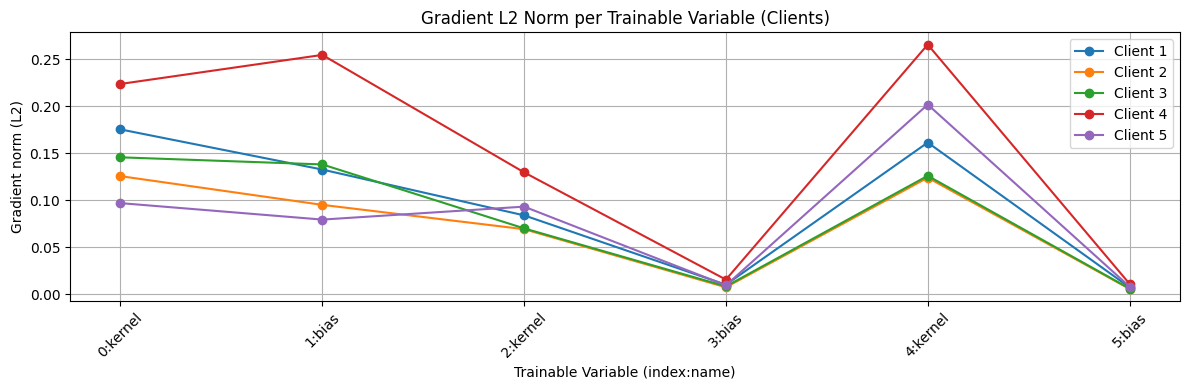

In [ ]:
# gradient norms per variable per client
n_vars = len(var_info)
client_grad_norms = np.zeros((len(client_models), n_vars))

for c in range(len(client_models)):
    for vi in range(n_vars):
        client_grad_norms[c, vi] = np.linalg.norm(all_client_grads[c][vi].ravel())

# plot
plt.figure(figsize=(12,4))
for c in range(len(client_models)):
    plt.plot(range(n_vars), client_grad_norms[c], marker='o', label=f'Client {c+1}')
plt.xticks(range(n_vars), [f"{i}:{var_info[i][0].split(':')[0]}" for i in range(n_vars)], rotation=45)
plt.xlabel("Trainable Variable (index:name)")
plt.ylabel("Gradient norm (L2)")
plt.title("Gradient L2 Norm per Trainable Variable (Clients)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


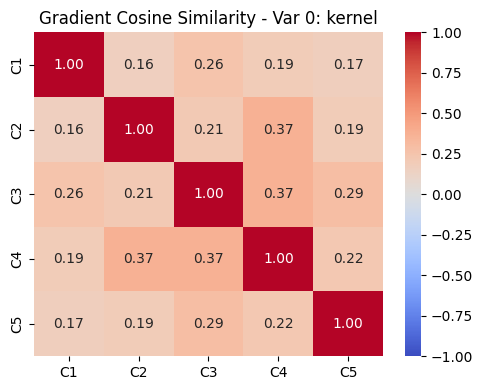

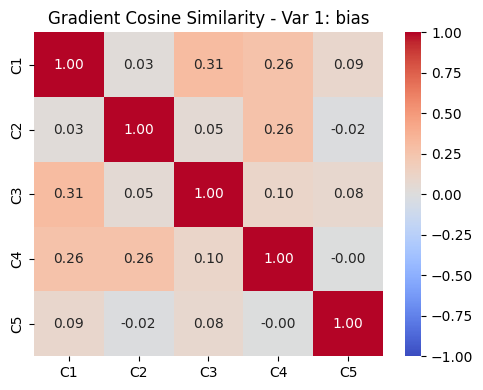

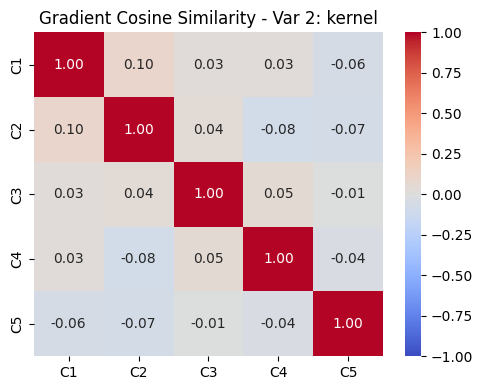

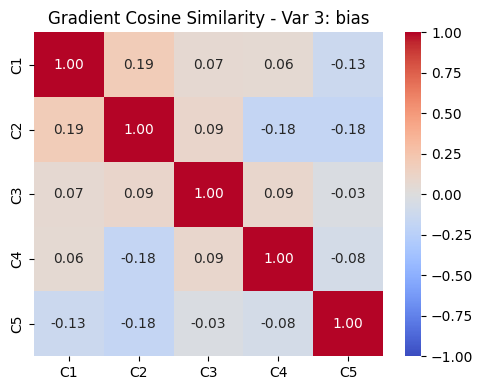

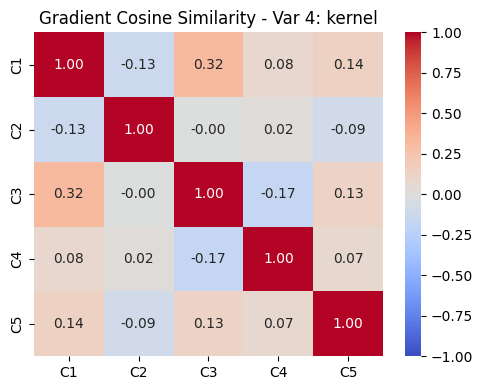

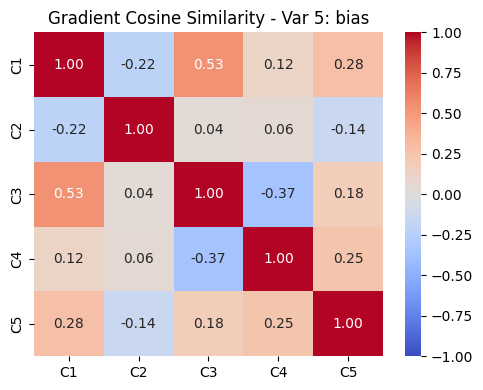

In [ ]:
for vi in range(n_vars):
    # build matrix (n_clients, dim)
    mats = np.stack([all_client_grads[c][vi].ravel() for c in range(len(client_models))], axis=0)
    # normalize small dims
    # compute cosine similarity (dot / norms)
    norms = np.linalg.norm(mats, axis=1, keepdims=True) + 1e-12
    mats_norm = mats / norms
    sim = mats_norm @ mats_norm.T
    plt.figure(figsize=(5,4))
    sns.heatmap(sim, annot=True, fmt=".2f", xticklabels=[f"C{i+1}" for i in range(len(client_models))],
                yticklabels=[f"C{i+1}" for i in range(len(client_models))], vmin=-1, vmax=1, cmap='coolwarm')
    plt.title(f"Gradient Cosine Similarity - Var {vi}: {var_info[vi][0].split(':')[0]}")
    plt.tight_layout()
    plt.show()


Batchwise grads for client 1
Batchwise grads for client 2
Batchwise grads for client 3
Batchwise grads for client 4
Batchwise grads for client 5


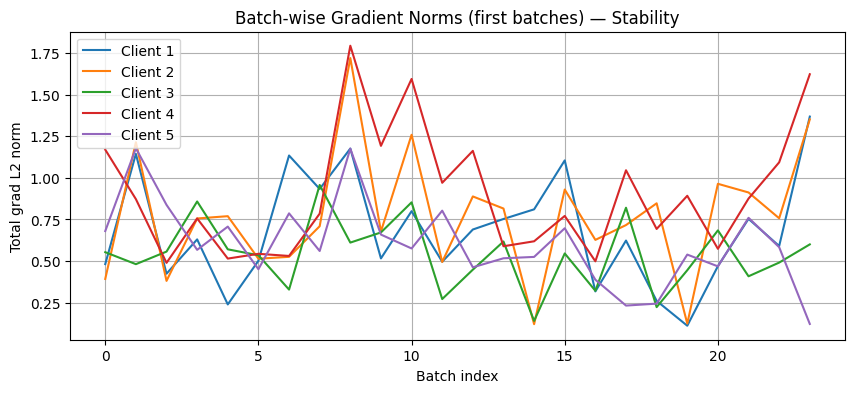

In [ ]:
def compute_batchwise_grad_norms(model, x_val, y_val, batch_size=128, max_batches=20):
    ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size)
    norms_per_batch = []
    bcount = 0
    for xb, yb in ds:
        if bcount >= max_batches: break
        with tf.GradientTape() as tape:
            preds = model(xb, training=False)
            loss = loss_fn(yb, preds)
        grads = tape.gradient(loss, model.trainable_variables)
        # compute total gradient norm across all vars for this batch
        total = 0.0
        for g in grads:
            if g is not None:
                total += np.sum(g.numpy().ravel()**2)
        norms_per_batch.append(math.sqrt(total))
        bcount += 1
    return np.array(norms_per_batch)

# compute for each client
max_batches = 30
batch_norms = []
for c, model in enumerate(client_models):
    print("Batchwise grads for client", c+1)
    bn = compute_batchwise_grad_norms(model, x_val, y_val, batch_size=128, max_batches=max_batches)
    batch_norms.append(bn)

# plot
plt.figure(figsize=(10,4))
for c in range(len(batch_norms)):
    plt.plot(batch_norms[c], label=f"Client {c+1}")
plt.xlabel("Batch index")
plt.ylabel("Total grad L2 norm")
plt.title("Batch-wise Gradient Norms (first batches) — Stability")
plt.legend()
plt.grid(True)
plt.show()


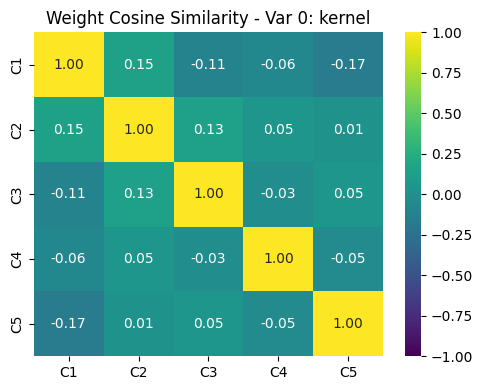

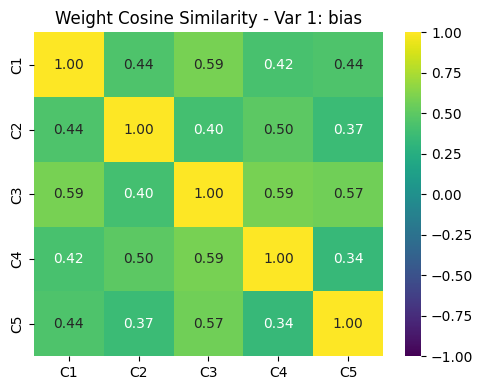

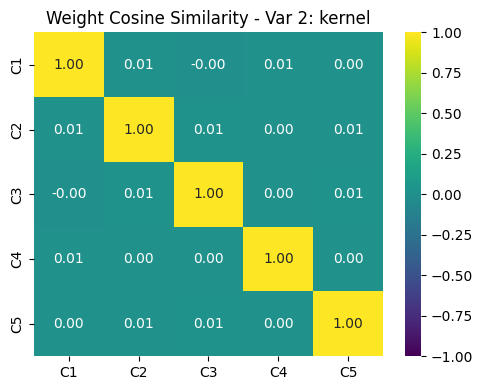

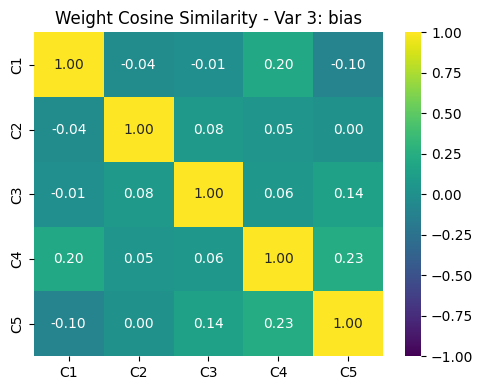

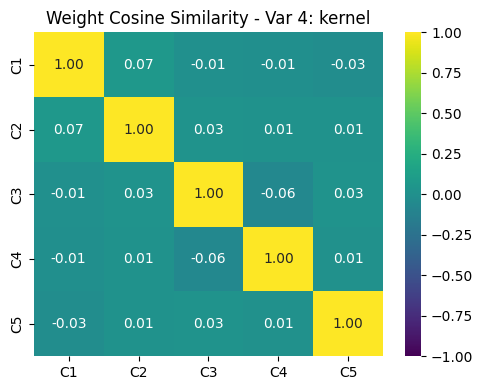

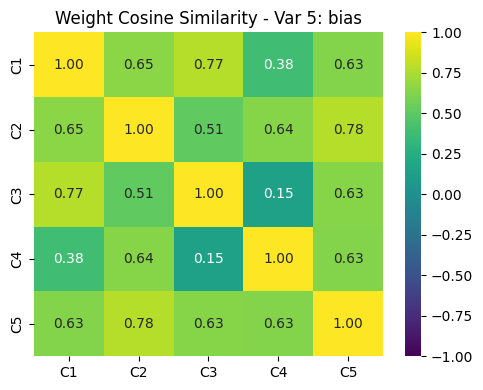

In [ ]:
# collect flattened weights per client per var
all_client_weights = []
for c in range(len(client_models)):
    ws = client_models[c].get_weights()  # list of arrays in same order as vars
    all_client_weights.append(ws)

# per variable similarity
for vi in range(n_vars):
    mats = np.stack([all_client_weights[c][vi].ravel() for c in range(len(client_models))], axis=0)
    norms = np.linalg.norm(mats, axis=1, keepdims=True) + 1e-12
    mats_norm = mats / norms
    sim = mats_norm @ mats_norm.T
    plt.figure(figsize=(5,4))
    sns.heatmap(sim, annot=True, fmt=".2f", xticklabels=[f"C{i+1}" for i in range(len(client_models))],
                yticklabels=[f"C{i+1}" for i in range(len(client_models))], vmin=-1, vmax=1, cmap='viridis')
    plt.title(f"Weight Cosine Similarity - Var {vi}: {var_info[vi][0].split(':')[0]}")
    plt.tight_layout()
    plt.show()


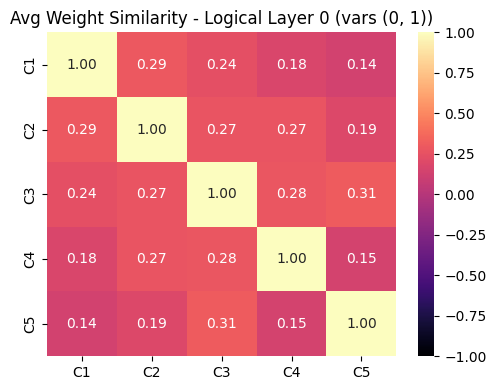

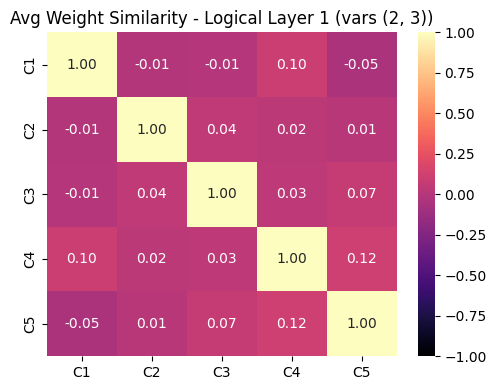

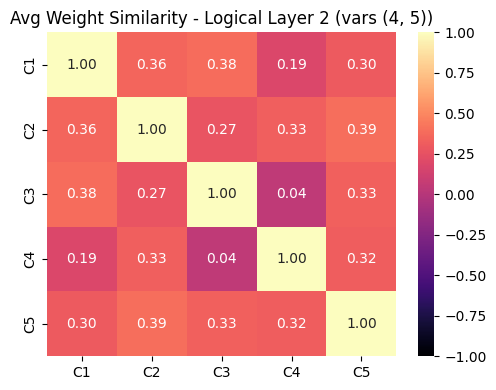

In [ ]:
# assuming variables are paired (kernel,bias) per layer
# build layer groups: e.g. [(0,1), (2,3), (4,5)] depending on var count
layer_pairs = []
i = 0
while i < n_vars:
    # try pair; if last odd, keep single
    if i+1 < n_vars:
        layer_pairs.append((i, i+1))
        i += 2
    else:
        layer_pairs.append((i,))
        i += 1

for li, pair in enumerate(layer_pairs):
    # compute average similarity across the pair
    sim_sum = np.zeros((len(client_models), len(client_models)))
    for vi in pair:
        mats = np.stack([all_client_weights[c][vi].ravel() for c in range(len(client_models))], axis=0)
        mats_norm = mats / (np.linalg.norm(mats, axis=1, keepdims=True)+1e-12)
        sim_sum += mats_norm @ mats_norm.T
    sim_avg = sim_sum / len(pair)
    plt.figure(figsize=(5,4))
    sns.heatmap(sim_avg, annot=True, fmt=".2f", xticklabels=[f"C{i+1}" for i in range(len(client_models))],
                yticklabels=[f"C{i+1}" for i in range(len(client_models))], vmin=-1, vmax=1, cmap='magma')
    plt.title(f"Avg Weight Similarity - Logical Layer {li} (vars {pair})")
    plt.tight_layout()
    plt.show()


In [ ]:
import os
os.makedirs('/content/plots', exist_ok=True)
# inside plotting loops: plt.savefig(f"/content/plots/gradient_sim_var{vi}.png")
